# OpenTH quickstart

A short tour of OpenTH in a notebook: a **steady** pipeline, a **transient** run with a plot, the **component/connection** API, and the **paper benchmarks**.

Install into the project venv first:

```bash
pip install -e ".[dev,notebook]"   # adds jupyterlab + matplotlib
jupyter lab
```

In [1]:
import sys, pathlib

# Import openth. If it isn't installed, fall back to the repo's src/ directory
# (works whether the notebook is launched from the repo root or examples/).
try:
    import openth  # noqa: F401
except ModuleNotFoundError:
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "openth").is_dir():
            sys.path.insert(0, str(base / "src"))
            break

import openth as th
print("OpenTH", th.__version__)

OpenTH 0.0.1


## 1. Steady state

A 100 m helium pipeline: fix the outlet pressure and the inlet mass flow, then solve for the
steady state. `add_pipe(..., n_cells=20)` subdivides it into 20 finite-volume cells.

In [2]:
model = th.Model(fluid=th.Fluid("helium"))
model.add_pipe("inlet", "outlet", length=100, diameter=0.5, n_cells=20)
model.pressure_boundary("outlet", p=200e3, T=300)
model.mass_flow_boundary("inlet", mdot=30, T=300)

result = model.steady_state(relaxation=0.5, max_outer_iterations=600)
print("converged:", result.converged, "in", result.iterations, "iterations")
print(f"inlet pressure : {model.pressure('inlet')/1e3:.1f} kPa")
print(f"mass flow      : {model.flow_through('inlet->outlet'):.3f} kg/s")

converged: True in 70 iterations
inlet pressure : 336.7 kPa
mass flow      : 30.000 kg/s


## 2. Transient + plot

The paper's blow-down case (Section 5.4): the upstream vessel pressure decays and the mass
flow follows. `run(...)` returns time histories that drop straight into matplotlib.

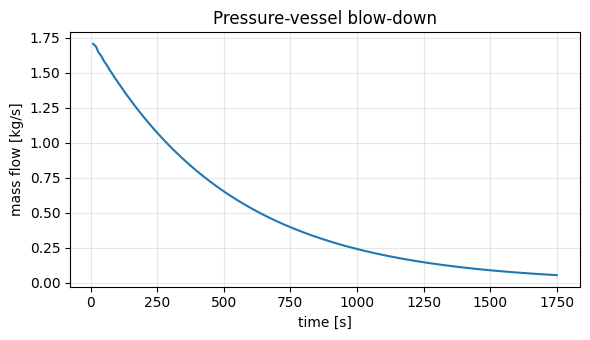

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from openth import benchmarks

blowdown = benchmarks.build_blowdown()
hist = blowdown.run(dt=10.0, duration=1750.0, record=("flow:pipe",),
                    alpha=0.6, relaxation=0.6)

plt.figure(figsize=(6, 3.5))
plt.plot(hist["t"], hist["flow:pipe"])
plt.xlabel("time [s]"); plt.ylabel("mass flow [kg/s]")
plt.title("Pressure-vessel blow-down"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Component / connection style (`th.Circuit`)

For loops and networks it can be tidier to build from component objects and join their
`.inlet` / `.outlet` ports. Here a blower drives a closed helium loop.

In [4]:
c = th.Circuit(fluid=th.Fluid("helium"))
blower = c.add(th.Pump(head_shutoff=120e3, curve=300.0))
hot  = c.add(th.Pipe(length=15, diameter=0.3, n_cells=6))
cold = c.add(th.Pipe(length=15, diameter=0.3, n_cells=6))

c.connect(blower.outlet, hot.inlet)
c.connect(hot.outlet, cold.inlet)
c.connect(cold.outlet, blower.inlet)
c.pressure_boundary(blower.inlet, p=300e3, T=300)   # closed loop: pin a reference pressure

c.solve_steady_state(relaxation=0.6)
print(f"loop mass flow : {c.flow(blower):.3f} kg/s")
print(f"blower rise    : {(c.pressure(blower.outlet) - c.pressure(blower.inlet))/1e3:+.1f} kPa")

loop mass flow : 12.641 kg/s
blower rise    : +72.1 kPa


## 4. The paper's benchmarks

`openth.benchmarks` builds and runs Greyvenstein's four Section 5 test cases (also available
from the command line as `openth benchmark <name>`).

In [5]:
for name in benchmarks.BENCHMARKS:
    print(name, "->", benchmarks.run(name))

steady_pipeline -> {'converged': True, 'mdot [kg/s]': 19.2695, 'P1/P2 (PCIM)': 1.2953, 'P1/P2 (exact)': 1.2953}


valve_closure -> {'pre-closure p_valve [kPa]': 698.4, 'peak p_valve [kPa]': 766.2, 'min p_valve [kPa]': 644.7, 'water hammer': True}


branching_network -> {'p_A initial [kPa]': 681.7, 'p_A peak [kPa]': 792.9, 'p_A min [kPa]': 629.8, 'steps': 333}


blowdown -> {'initial mdot [kg/s]': 1.7071, 'final mdot [kg/s]': 0.0538, 'monotonic decay': True, 'steps': 175}
